In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def Z_term(tau_slow, T_ext):
    return tau_slow * (1 - np.exp(-T_ext / tau_slow))

def C3(z, T_ext, R0, u_ext, r_slow_0):
    return (z-T_ext) / R0 * np.pow(u_ext,3)

def C2(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z - 2 * T_ext) * np.pow(u_ext, 2)

def C1(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z * R0 - T_ext * R0 - z * r_slow_0 / R0) * u_ext

def C0(z, T_ext, R0, u_ext, r_slow_0):
    return z * (np.pow(R0, 2) - r_slow_0)

def r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow):
    r_j_squared = np.pow((R0 + w * u_ext), 2)
    return r_j_squared - (r_j_squared - r_slow_0) * np.exp(- T_ext / tau_slow)


# approximations
def Z_term_approx_short(tau_slow, T_ext):
    return T_ext

def C3_approx_short(z, T_ext, R0, u_ext, r_slow_0):
    return 0

def C2_approx_short(z, T_ext, R0, u_ext, r_slow_0):
    return T_ext * np.pow(u_ext, 2)

def C1_approx_short(z, T_ext, R0, u_ext, r_slow_0):
    return T_ext * R0 * u_ext

# approximations
def Z_term_approx_long(tau_slow, T_ext):
    return tau_slow

def C3_approx_long(z, T_ext, R0, u_ext, r_slow_0):
    return (z-T_ext) / R0 * np.pow(u_ext,3)

def C2_approx_long(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z - 2 * T_ext) * np.pow(u_ext, 2)

def C1_approx_long(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z * R0 - T_ext * R0 - z * r_slow_0 / R0) * u_ext

In [3]:
def delta_w_single(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    print(f"z : {z}")
    print(f"c3: {alpha * ri *c3}")
    print(f"c2: {alpha * ri *c2}")
    print(f"c1: {alpha * ri *c1}")
    print(f"c0: {alpha * ri *c0}")
    
    return stim, trace_after_stim


def delta_w_single_approx(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w, type):
    if type == 'short':
        z = Z_term_approx_short(tau_slow, T_ext)
        c3 = C3_approx_short(z, T_ext, R0, u_ext, r_slow_0)
        c2 = C2_approx_short(z, T_ext, R0, u_ext, r_slow_0)
        c1 = C1_approx_short(z, T_ext, R0, u_ext, r_slow_0)
        c0 = 0
        
        ri = R0 + u_ext
        trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
        
        stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
        
        print(f"z : {z}")
        print(f"c3: {alpha * ri *c3}")
        print(f"c2: {alpha * ri *c2}")
        print(f"c1: {alpha * ri *c1}")
        print(f"c0: {alpha * ri *c0}")
        
        return stim, trace_after_stim
    else:
        z = Z_term_approx_long(tau_slow, T_ext)
        c3 = C3_approx_long(z, T_ext, R0, u_ext, r_slow_0)
        c2 = C2_approx_long(z, T_ext, R0, u_ext, r_slow_0)
        c1 = C1_approx_long(z, T_ext, R0, u_ext, r_slow_0)
        c0 = 0
        
        ri = R0 + u_ext
        trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
        
        stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
        
        print(f"z : {z}")
        print(f"c3: {alpha * ri *c3}")
        print(f"c2: {alpha * ri *c2}")
        print(f"c1: {alpha * ri *c1}")
        print(f"c0: {alpha * ri *c0}")
        
        return stim, trace_after_stim

def delta_w(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    print(f"z : {z}")
    print(f"c3: {alpha * ri *c3}")
    print(f"c2: {alpha * ri *c2}")
    print(f"c1: {alpha * ri *c1}")
    print(f"c0: {alpha * ri *c0}")
    
    # after_stim 
    u_ext = 0
    T_ext *= 3
    r_slow_0 = trace_after_stim
    
    
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0
    
    after_stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    return stim + after_stim




def fix_points(T_ext, R0, u_ext, r_slow_0, tau_slow):
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    fp_1 = (-c2 + np.sqrt(np.pow(c2,2) - 4 * c3 * c1)) / (2*c3)
    fp_2 = (-c2 - np.sqrt(np.pow(c2,2) - 4 * c3 * c1)) / (2*c3)
    
    return fp_1, fp_2
    

z : 0.09516258196404048
c3: -0.2089764591534514
c2: 0.24620470816930975
c1: 0.017342431474191546
c0: 0.0
z : 0.1
c3: 0.0
c2: 0.28800000000000003
c1: 0.019200000000000002
c0: 0.0


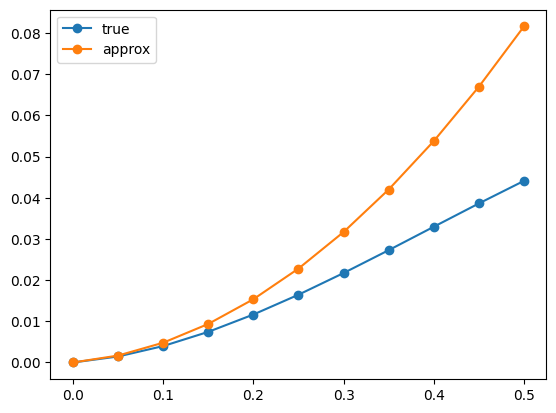

In [4]:
R_NULL = 2
ALPHA = 1e-4
R_SLOW_NULL = R_NULL**2

tau_slow = 1.0
ws = np.arange(0, 0.501, 0.05)

T_EXT = 0.1
U_EXT = 30
results_r = delta_w_single(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
results_r_approx = delta_w_single_approx(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws, 'short')

plt.plot(ws, results_r[0],'-o', label='true')
plt.plot(ws, results_r_approx[0], '-o', label='approx')


# def sigmoid_approx(w):
#     return 1.24 / (np.sqrt(1+ ((1.24-w) / w -1) * np.exp(-0.0341)))

# plt.plot(ws, np.exp(ws**2 *0.49) - 1,'-o', label='exp approx')
def quadratic(w):
    c1 = 0.038400000000000004
    c2 = 0.5760000000000001
    
    return (c1 * w * np.exp(c1)) / (c1 + c2 * w * (1-np.exp(c1)))

def quadratic2(w):
    c1 = 0.038400000000000004
    c2 = 0.5760000000000001
    
    return w**2 * c2

def quadratic3(w):
    c1 = 0.038400000000000004
    c2 = 0.5760000000000001
    
    return w/(1-c2*w)

# plt.plot(ws, quadratic(ws) ,'-o', label='lin approx')
# plt.plot(ws, quadratic2(ws) ,'-o', label='lin approx')
# plt.plot(ws, quadratic3(ws) ,'-o', label='lin approx 3')

plt.legend()

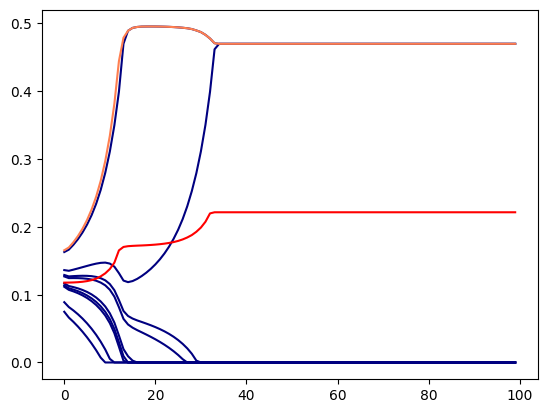

In [5]:
xs = np.random.normal(0.12, 0.02, size=10)
n_runs = 100

xss = np.zeros((n_runs, xs.size))
fps = np.zeros(n_runs)

for i in range(n_runs):
    xss[i] = xs
    c2 = 0.5760000000000001
    
    xs = np.clip(xs + c2*np.pow(xs, 2), 0, 0.5)
    xs = np.clip(xs - (np.mean(xs) - 0.12), 0, 0.5)
    
    fps[i] = np.sqrt(np.sum(np.pow(xs[1:], 2)) / xs[1:].size)
    
plt.plot(np.arange(n_runs), xss[:, 1:], color='navy')
plt.plot(np.arange(n_runs), xss[:, 0], color='coral')
plt.plot(np.arange(n_runs), fps, color='red')


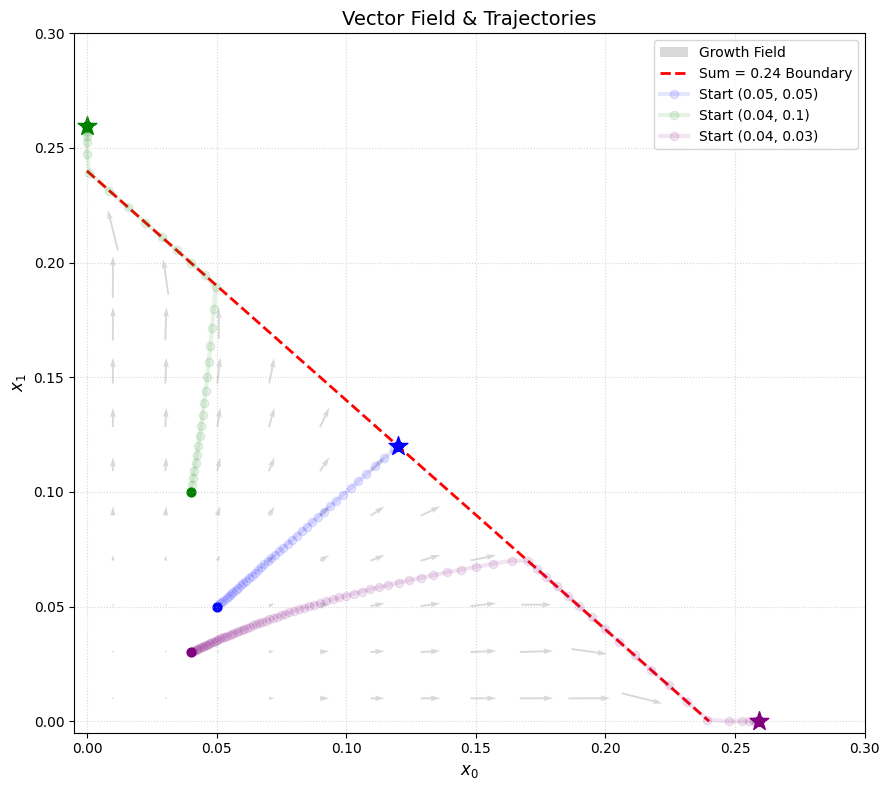

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_trajectory(start_xs, n_runs, c2=0.28800000):
    xs = np.array(start_xs, dtype=float)
    history = np.zeros((n_runs, xs.size))
    for i in range(n_runs):
        history[i] = xs
        # Growth step
        xs_growth = xs + c2 * np.power(xs, 2)
        # Mean-centering step
        m = np.mean(xs_growth)
        shift = max(0, m - 0.12)
        xs = np.clip(xs_growth - shift, 0, 0.5)
    return history

def get_delta_vectorized(X0, X1, c2=0.576):
    G0 = X0 + c2 * X0**2
    G1 = X1 + c2 * X1**2
    mean_G = (G0 + G1) / 2
    shift = np.where(mean_G > 0.12, mean_G - 0.12, 0)
    F0 = np.clip(G0 - shift, 0, 0.5)
    F1 = np.clip(G1 - shift, 0, 0.5)
    return F0 - X0, F1 - X1

# Grid setup
x_range = np.linspace(0.01, 0.5, 25)
y_range = np.linspace(0.01, 0.5, 25)
X0, X1 = np.meshgrid(x_range, y_range)
mask = (X0 + X1 <= 0.241) # Keep vector field visualization mainly in growth zone

U, V = get_delta_vectorized(X0, X1)
U[~mask] = np.nan # Clean up field outside the target sum
V[~mask] = np.nan

plt.figure(figsize=(9, 8))

# 1. Quiver Plot (Neutral gray)
plt.quiver(X0, X1, U, V, color='gray', alpha=0.3, pivot='mid', label='Growth Field')

# 2. Boundary Line
line_x = np.linspace(0, 0.24, 100)
plt.plot(line_x, 0.24 - line_x, 'r--', linewidth=2, label='Sum = 0.24 Boundary')

# 3. Specific Trajectories
trajectories = [(0.05, 0.05), (0.04, 0.1), (0.04, 0.03)]
colors = ['blue', 'green', 'purple']

for start, color in zip(trajectories, colors):
    traj = simulate_trajectory(start, n_runs=500)
    plt.plot(traj[:, 0], traj[:, 1], '-o',color=color, linewidth=3, label=f'Start {start}', alpha=0.1)
    plt.scatter(traj[0, 0], traj[0, 1], color=color, s=40)
    plt.scatter(traj[-1, 0], traj[-1, 1], color=color, s=200, marker="*")

plt.title("Vector Field & Trajectories", fontsize=14)
plt.xlabel("$x_0$", fontsize=12)
plt.ylabel("$x_1$", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(-0.005, 0.3)
plt.ylim(-0.005, 0.3)
plt.legend()
plt.tight_layout()
plt.show()

z : 0.9816843611112658
c3: -0.2641026184027642
c2: -0.17692314208331708
c1: -0.02851283788888456
c0: 0.0
z : 1.0
c3: -0.2625
c2: -0.175
c1: -0.028
c0: 0.0


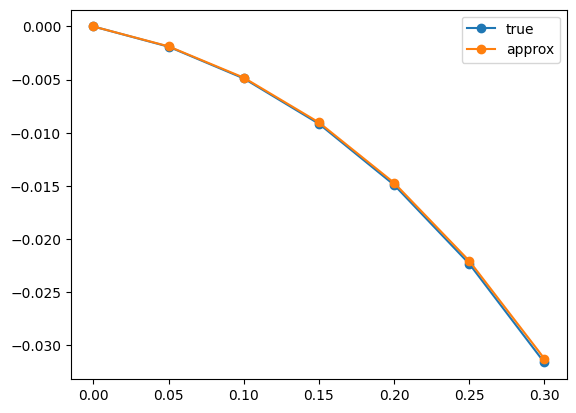

In [7]:
R_NULL = 2
ALPHA = 2e-4
R_SLOW_NULL = R_NULL**2

tau_slow = 1.0
ws = np.arange(0, 0.301, 0.05)

T_EXT = 4
U_EXT = 5
results_p = delta_w_single(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
results_p_approx = delta_w_single_approx(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws, 'long')

plt.plot(ws, results_p[0],'-o', label='true')
plt.plot(ws, results_p_approx[0], '-o', label='approx')

plt.legend()

In [8]:
R_NULL = 2
ALPHA = 2e-4
R_SLOW_NULL = R_NULL**2

tau_slow = 1.0
ws = np.arange(0, 0.501, 0.1)

T_EXT = 0.1
U_EXT = 30
results_r = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

T_EXT = 4
U_EXT = 5
results_p = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

z : 0.09516258196404048
c3: -0.4179529183069028
c2: 0.4924094163386195
c1: 0.03468486294838309
c0: 0.0
z : 0.9816843611112658
c3: -0.2641026184027642
c2: -0.17692314208331708
c1: -0.02851283788888456
c0: 0.0


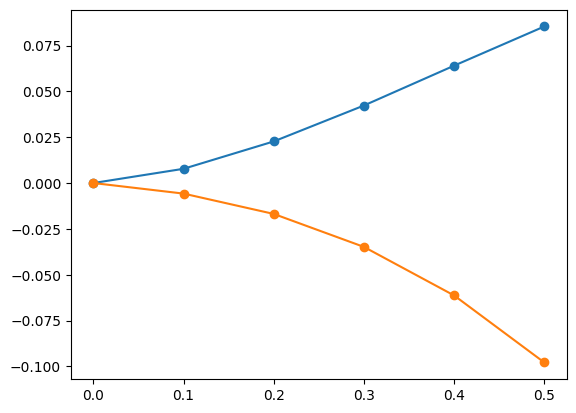

In [9]:
plt.plot(ws, results_r,'-o',)
plt.plot(ws, results_p, '-o')

z : 0.09516258196404048
c3: -0.0693867149532944
c2: 0.16349531401868225
c1: 0.023032916801660648
c0: 0.0
z : 0.18126924692201818
c3: -0.2686692394623019
c2: 0.2750323042150793
c1: 0.04144731593022927
c0: 0.0
z : 0.3296799539643607
c3: -1.008653160323702
c2: 0.36153873587051927
c1: 0.06613677652182394
c0: 0.0
z : 0.4511883639059736
c3: -2.1345169052236908
c2: 0.29369323791052393
c1: 0.07710606559204658
c0: 0.0
z : 0.5506710358827784
c3: -0.05454071090064223
c2: 0.004551146919229332
c1: 0.010546972511794489
c0: 0.0
z : 0.6321205588285577
c3: -0.08047362775625301
c2: -0.009068353307503612
c1: 0.009248439117999037
c0: 0.0
z : 0.8646647167633873
c3: -0.24835459320800907
c2: -0.12302551184961082
c1: -0.009473469826562884
c0: 0.0
z : 0.9816843611112658
c3: -0.6602565460069106
c2: -0.44230785520829274
c1: -0.07128209472221139
c0: 0.0


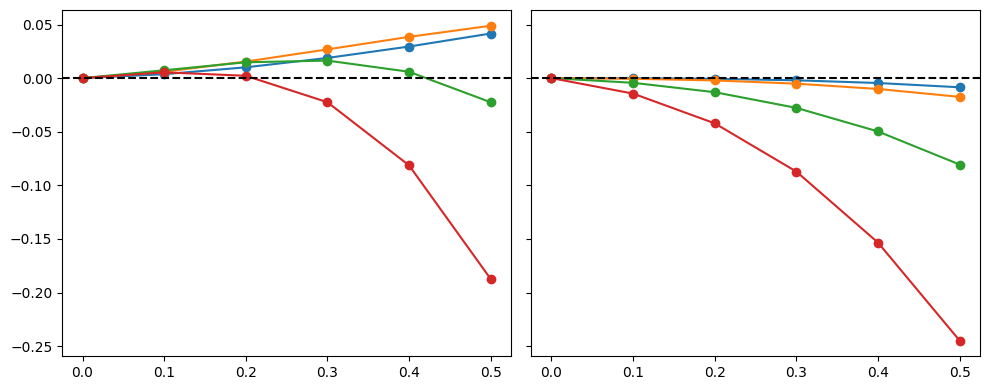

In [10]:
fig, axs = plt.subplot_mosaic([["Short", "Long"]], figsize=(10,4), sharey=True)

ws = np.arange(0,0.501, 0.1)

ts_short = np.array([0.1, 0.2, 0.4, 0.6])
ts_long = np.array([0.8, 1, 2, 4])

params = [ts_short, ts_long]

for (name, ax), param in zip(axs.items(), params):
    
    R_NULL = 2
    ALPHA = 5e-4
    R_SLOW_NULL = R_NULL**2
    u_ext = 5
    tau_slow = 1.0
    
    if name == 'Short':
        for t_ext in param:
            u_ext = 15
            ax.plot(ws, delta_w(t_ext, R_NULL, u_ext, R_SLOW_NULL, tau_slow, ALPHA, ws), marker='o')
        ax.axhline(0, color='black', linestyle='--')
    if name == 'Long':
        for t_ext in param:
            ax.plot(ws, delta_w(t_ext, R_NULL, u_ext, R_SLOW_NULL, tau_slow, ALPHA, ws), marker='o')
        ax.axhline(0, color='black', linestyle='--')
            
fig.tight_layout()

## Gameplay + Reward stimulation

In [11]:
R_NULL = 2
ALPHA = 2e-4
R_SLOW_NULL = R_NULL**2
tau_slow = 1.
ws = np.arange(0, 0.501, 0.1)

T_EXT = 0.1
U_EXT = 25
results_r = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

T_EXT = 4
U_EXT = 5
results_p = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)

t_gp = 0.1

T_EXT = t_gp
U_EXT = 5
dw_gp, trace = delta_w_single(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
results_gp = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
T_EXT = 0.1
U_EXT = 25
dw_gp_r, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw_gp)
T_EXT = t_gp
U_EXT = 10
dw_gp_r_gp, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw_gp+dw_gp_r)
results_gp_r_gp = dw_gp + dw_gp_r + dw_gp_r_gp

T_EXT = t_gp
U_EXT = 10
dw_gp2, trace = delta_w_single(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, ws)
T_EXT = 4
U_EXT = 5
dw_gp_p, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw_gp)
results_gp_p = dw_gp2 + dw_gp_p

z : 0.09516258196404048
c3: -0.20407857339204238
c2: 0.28852114238590987
c1: 0.024387794260581862
c0: 0.0
z : 0.9816843611112658
c3: -0.2641026184027642
c2: -0.17692314208331708
c1: -0.02851283788888456
c0: 0.0
z : 0.09516258196404048
c3: -0.00042327407814645823
c2: 0.00299207110622425
c1: 0.0012645522949931334
c0: 0.0
z : 0.09516258196404048
c3: -0.00042327407814645823
c2: 0.00299207110622425
c1: 0.0012645522949931334
c0: 0.0
z : 0.09516258196404048
c3: -0.20407857339204238
c2: 0.28852114238590987
c1: [0.02438779 0.02301243 0.02133142 0.01934478 0.0170525  0.01445459]
c0: [ 0.         -0.00011003 -0.00024451 -0.00040344 -0.00058682 -0.00079466]
z : 0.09516258196404048
c3: -0.005804901643151428
c2: 0.02051705901410915
c1: [ 0.00433561  0.00234465 -0.00106029 -0.00588141 -0.01212078 -0.01978034]
c0: [ 0.         -0.00039819 -0.00107918 -0.0020434  -0.00329128 -0.00482319]
z : 0.09516258196404048
c3: -0.005804901643151428
c2: 0.02051705901410915
c1: 0.004335607868547886
c0: 0.0
z : 0.981

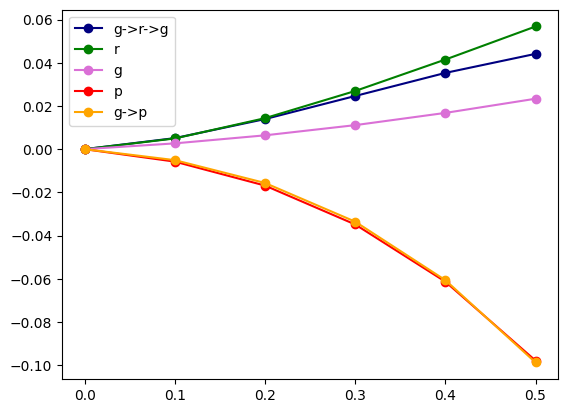

In [12]:
plt.plot(ws, results_gp_r_gp, '-o', label='g->r->g', color='navy')
plt.plot(ws, results_r, '-o', label='r', color='green')
plt.plot(ws, results_gp * 20, '-o', label='g', color='orchid')
plt.plot(ws, results_p, '-o', label='p', color='red')
plt.plot(ws, results_gp_p, '-o', label='g->p', color='orange')

plt.legend()
plt.show()

z : 0.09516258196404048
c3: -0.005804901643151428
c2: 0.02051705901410915
c1: 0.004335607868547886
c0: 0.0
z : 0.09516258196404048
c3: -0.0
c2: 0.0
c1: [ 0.  0.  0.  0.  0. -0.]
c0: [ 0.00000000e+00 -1.81118340e-05 -4.34684016e-05 -7.60697029e-05
 -1.15915738e-04 -1.63006506e-04]
z : 0.09516258196404048
c3: -0.005804901643151428
c2: 0.02051705901410915
c1: [ 4.33560787e-03  3.84395991e-03  3.15565278e-03  2.27068646e-03
  1.18906096e-03 -8.92237148e-05]
c0: [ 0.00000000e+00 -9.83295907e-05 -2.35991018e-04 -4.12984281e-04
 -6.29309381e-04 -8.84966317e-04]
z : 0.09516258196404048
c3: -0.0
c2: 0.0
c1: [ 0.  0.  0.  0. -0. -0.]
c0: [ 0.00000000e+00 -3.30743115e-05 -7.95212970e-05 -1.39409093e-04
 -2.12795869e-04 -2.99729748e-04]
z : 0.09516258196404048
c3: -0.005804901643151428
c2: 0.02051705901410915
c1: [ 0.00433561  0.0034378   0.00217699  0.00055133 -0.00144076 -0.00380059]
c0: [ 0.         -0.00017956 -0.00043172 -0.00075686 -0.00115527 -0.00162724]
z : 0.09516258196404048
c3: -0.0
c2

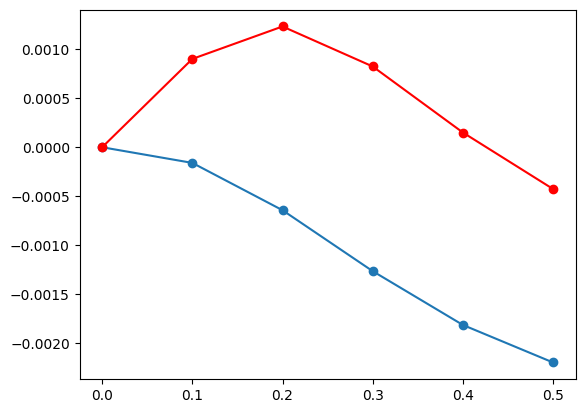

In [13]:
dw = np.zeros_like(ws)
trace = R_NULL**2

N = 50

traces = np.zeros((N, ws.size))

for i in range(N):
    T_EXT = 0.1
    U_EXT = 10
    dw_gp, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw)
    dw_gp_2, trace = delta_w_single(T_EXT, R_NULL, 0, trace, tau_slow, ALPHA, ws+dw)
    # traces[i] = trace
    dw += dw_gp + dw_gp_2
    
T_EXT = 0.1
U_EXT = 20
dw_gp_r, trace = delta_w_single(T_EXT, R_NULL, U_EXT, trace, tau_slow, ALPHA, ws+dw)
    
plt.plot(ws, dw_gp, '-o')
plt.plot(ws, dw_gp_r, '-o', color='red')

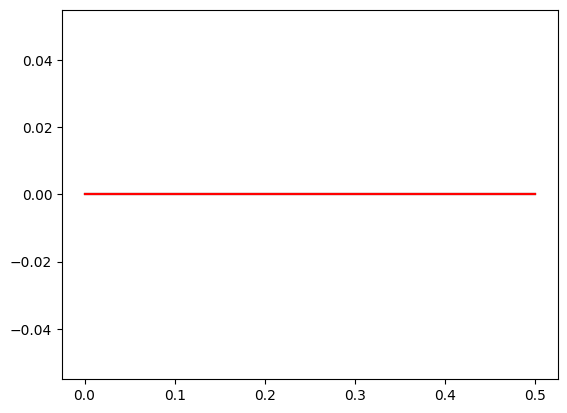

In [14]:
plt.plot(ws, traces[0:2].T, color='black')
plt.plot(ws, traces[-2:].T, color='red')